In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.api as sm
import joblib
from math import ceil
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, auc, precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
print("Library imports successful")

Library imports successful


https://www.kaggle.com/datasets/START-UMD/gtd

https://www.start.umd.edu/sites/default/files/2024-10/Codebook.pdf


In [2]:
df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')
df = df.copy()
df.sample(10, random_state=42)
# Random_state -- save time for running the code again

C:\Users\hungh\AppData\Local\Temp\ipykernel_9052\226401783.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
83552,200706120042,2007,6,12,NaN,0,NaN,153,Pakistan,6,...,NaN,"�Student leader gunned down in Karachi,� Pakis...",�Selection list: Pakistan press Nawa-e Waqt 14...,�Selection list: Pakistan press Ummat 14 Jun 0...,CETIS,-9,-9,0,-9,NaN
30191,198702160006,1987,2,16,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
51303,199205060002,1992,5,6,NaN,0,NaN,92,India,6,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
73581,200201030001,2002,1,3,NaN,0,NaN,167,Russia,9,...,NaN,�At least 6 civilians reported killed in Chech...,NaN,NaN,CETIS,0,0,0,0,"200201030001, 200201030002, 200201030003"
17703,198212310013,1982,12,31,NaN,0,NaN,69,France,8,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
174077,201704200007,2017,4,20,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Roadside Bomb Hits AU Military Convo...","""Program Summary: Radio Andalus in Somali 1030...",NaN,START Primary Collection,0,1,1,1,NaN
132395,201405240203,2014,5,24,NaN,1,NaN,195,Sudan,11,...,NaN,"""Peacekeepers in North Darfur's Kabkabiya 'Sho...",NaN,NaN,START Primary Collection,0,0,0,0,"201405240202, 201405240203, 201405240204"
12791,198102010004,1981,2,1,NaN,0,NaN,83,Guatemala,2,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,0,-9,NaN
154258,201510150035,2015,10,15,2015-10-15 00:00:00,0,NaN,92,India,6,...,NaN,"""Maoist arrested in Latehar district, arms sei...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
28720,198607230002,1986,7,23,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN


In [3]:
print(df.shape)

(181691, 135)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(df[num_cols].dtypes.count())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(df[cat_cols].dtypes.count())


77
58


In [6]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

0
(181691, 135)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [8]:
df.dtypes.value_counts()

object     58
float64    55
int64      22
Name: count, dtype: int64

In [9]:
print(num_cols)

['eventid', 'iyear', 'imonth', 'iday', 'extended', 'country', 'region', 'latitude', 'longitude', 'specificity', 'vicinity', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype2', 'attacktype3', 'targtype1', 'targsubtype1', 'natlty1', 'targtype2', 'targsubtype2', 'natlty2', 'targtype3', 'targsubtype3', 'natlty3', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claim2', 'claimmode2', 'claim3', 'claimmode3', 'compclaim', 'weaptype1', 'weapsubtype1', 'weaptype2', 'weapsubtype2', 'weaptype3', 'weapsubtype3', 'weaptype4', 'weapsubtype4', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'property', 'propextent', 'propvalue', 'ishostkid', 'nhostkid', 'nhostkidus', 'nhours', 'ndays', 'ransom', 'ransomamt', 'ransomamtus', 'ransompaid', 'ransompaidus', 'hostkidoutcome', 'nreleased', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']


In [174]:
print(cat_cols)

['approxdate', 'resolution', 'country_txt', 'region_txt', 'provstate', 'city', 'location', 'summary', 'alternative_txt', 'attacktype1_txt', 'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1_txt', 'targtype2_txt', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2_txt', 'targtype3_txt', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'claimmode_txt', 'claimmode2_txt', 'claimmode3_txt', 'weaptype1_txt', 'weapsubtype1_txt', 'weaptype2_txt', 'weapsubtype2_txt', 'weaptype3_txt', 'weapsubtype3_txt', 'weaptype4_txt', 'weapsubtype4_txt', 'weapdetail', 'propextent_txt', 'propcomment', 'divert', 'kidhijcountry', 'ransomnote', 'hostkidoutcome_txt', 'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'related']


In [10]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

gsubname3           181671
weapsubtype4_txt    181621
weapsubtype4        181621
weaptype4_txt       181618
weaptype4           181618
                     ...  
guncertain1            380
ishostkid              178
specificity              6
multiple                 1
doubtterr                1
Length: 106, dtype: int64

In [12]:
df = df.rename(columns={'iyear': 'Year', 'imonth': 'Month', 'country_txt': 'Country', 'region_txt': 'Region', 'attacktype1_txt': 'Attack_Type'
                        , 'weaptype1_txt': 'Weapon_Type', 'natlty1_txt': 'Nationality'})

#### Building Context with Data Visualization

<Axes: ylabel='Region'>

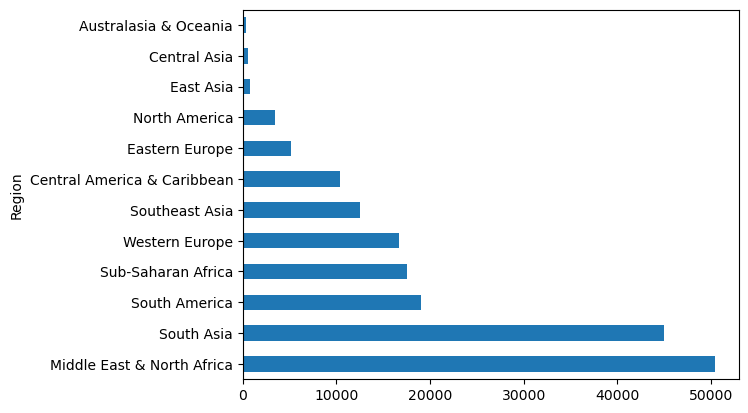

In [13]:
incidents_per_region = df.groupby('Region').size().sort_values(ascending=False)
incidents_per_region.plot(kind='barh')

In [37]:
# fig, ax = plt.subplots(figsize=(8,8))
# ax = sns.barploth(df,incidents_per_region )

In [14]:
# 1 - Yes (Military); 0 - Everything Else
df['ismilitary'] = df['targtype1_txt'].apply(lambda x: 1 if x == 'Military' else 0)
# Unbalanced Dataset 
df['ismilitary'].value_counts()

ismilitary
0    153707
1     27984
Name: count, dtype: int64

In [15]:
df['ismilitary'].sample(10)

23172     0
141617    0
106344    1
14854     0
155997    0
172898    1
32353     1
138082    0
167634    0
155911    0
Name: ismilitary, dtype: int64

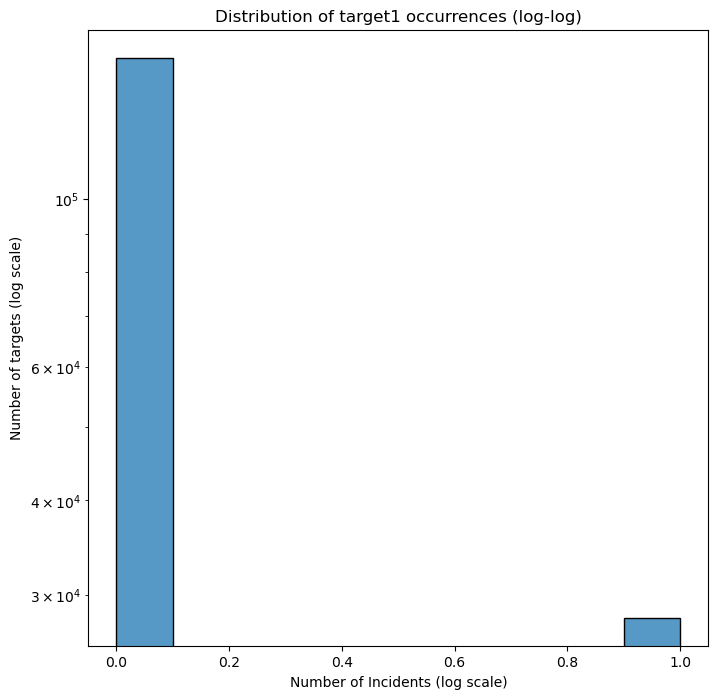

In [16]:
fig, ax = plt.subplots(figsize=(8,8))
sns.histplot(data = df, x = df['ismilitary'], bins=10, log=True)
plt.xlabel('Number of Incidents (log scale)')
plt.ylabel('Number of targets (log scale)')
plt.title('Distribution of target1 occurrences (log-log)')
plt.show()

In [17]:
north_america = df[df['Region'] == 'North America']
north_america.shape

(3456, 136)

In [18]:
df['Nationality'].isnull().sum()

np.int64(1559)

In [19]:
df['Nationality'].value_counts() 

Nationality
Iraq                                  24113
Pakistan                              13900
India                                 12098
Afghanistan                           10931
Colombia                               7922
                                      ...  
Commonwealth of Independent States        1
St. Lucia                                 1
Saba (Netherlands Antilles)               1
Tuvalu                                    1
Marshall Islands                          1
Name: count, Length: 215, dtype: int64

### Statify 
Success to Fail Attack: 9:1 unbalanced

Our target ['success'] holds unbalance distribution toward to 1 (attack went successful) than 0 (fail); 
hence, statify = y help with train/test set by giving more weight to class 0. 

Classification → use stratify=y (always safe).
Regression: Not recommended

In [20]:
# 3. Create X, y AFTER cleaning
X = df[['Year', 'Month', 'Country', 'Region', 'Attack_Type',
        'Weapon_Type', 'ismilitary', 'Nationality']]
y = df['success']

In [22]:
df[X.columns].sample(10)

,Year,Month,Country,Region,Attack_Type,Weapon_Type,ismilitary,Nationality
128808,2014,3,Iraq,Middle East & North Africa,Bombing/Explosion,Explosives,0,Iraq
103073,2011,9,India,South Asia,Unarmed Assault,Melee,0,India
30757,1987,4,United Kingdom,Western Europe,Bombing/Explosion,Explosives,0,Great Britain
140236,2014,11,Iraq,Middle East & North Africa,Hostage Taking (Kidnapping),Unknown,0,Iraq
65075,1997,4,Panama,Central America & Caribbean,Unknown,Unknown,0,Panama
11899,1980,9,El Salvador,Central America & Caribbean,Bombing/Explosion,Explosives,0,El Salvador
48109,1991,9,Guatemala,Central America & Caribbean,Bombing/Explosion,Explosives,0,Guatemala
132177,2014,5,Iraq,Middle East & North Africa,Bombing/Explosion,Explosives,0,Iraq
89813,2008,12,India,South Asia,Armed Assault,Firearms,0,India
171699,2017,2,Somalia,Sub-Saharan Africa,Armed Assault,Firearms,1,Somalia


In [23]:
print(df[X.columns].isnull().sum())

Year              0
Month             0
Country           0
Region            0
Attack_Type       0
Weapon_Type       0
ismilitary        0
Nationality    1559
dtype: int64


In [24]:
y.value_counts()

success
1    161632
0     20059
Name: count, dtype: int64

In [25]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
        )

# 5. Identify numeric vs categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 6. Transform pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
    ])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='constant', fill_value='Unknown')),  # fill missing first (natly1_txt)
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ])

# 7. Column transformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
    ])


In [26]:
#8. Log Reg model pipeline
log_reg_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(solver='saga'))
    ])

# 9. Fit model
log_reg_model.fit(X_train, y_train)
log_score = log_reg_model.score(X_test, y_test)
y_pred_lr = log_reg_model.predict(X_test)
print(f"Logisitic Regression Score: {log_score:.4f}")
print(f"Logisitic Regression Accurary: {log_score *100}")

Logisitic Regression Score: 0.8929
Logisitic Regression Accurary: 89.29249566581359


In [ ]:
# Save the model to a file
lg_metadata = {
    "model_name": "lg_terrorist_success_rate",
    "trained_date": "2025-12-12",
    "training_data_description": (
        "Predicting a terrorist attack's success rate based on "
        "Year, Month, Country, Region, Attack_Type, Weapon_Type, "
        "ismilitary, and Nationality"
    ),
    "accuracy": 0.89,
    "author": "Hung Nguyen"
}

# Save the model and metadata to a file
joblib.dump({'model': log_reg_model, 'metadata': lg_metadata}, '../model/lg_terrorist_success_rate.joblib')
print("Logisitic Regression saved successfully with metadata.")

Logisitic Regression saved successfully with metadata.


In [28]:
# Get feature names from preprocessor
feature_names = log_reg_model.named_steps["preprocess"].get_feature_names_out()

# Clean feature names: remove "num__" and "cat__"
clean_feature_names = [name.split("__", 1)[1] for name in feature_names]

# Extract coefficients from the logistic regression model inside the pipeline
coefficients = log_reg_model.named_steps["model"].coef_[0]

# Combine into a DataFrame
coef_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Coefficient": coefficients}).sort_values("Coefficient", ascending=False)

print("\n--- Logistic Regression Coefficients ---")
print(coef_df.head(15))



--- Logistic Regression Coefficients ---
                                               Feature  Coefficient
222    Attack_Type_Hostage Taking (Barricade Incident)     1.985430
364                                Nationality_Myanmar     1.240796
177                                 Country_Tajikistan     1.212568
332                                  Nationality_Kenya     1.174275
232                                  Weapon_Type_Melee     1.116030
266                               Nationality_Cambodia     1.110905
175                                      Country_Syria     1.108200
230                               Weapon_Type_Firearms     1.095376
237  Weapon_Type_Vehicle (not to include vehicle-bo...     1.057810
315                               Nationality_Honduras     1.037592
129                                  Country_Nicaragua     1.015027
140                                       Country_Peru     0.976893
223            Attack_Type_Hostage Taking (Kidnapping)     0.965580
40    

### Note: 
Lingear Regression doesn't produce a good R2 score. My MVP is to predict if a terrorist attack will succeed or not

In [30]:
 # 8. Random Forest Classifier model pipeline
rfc_model = Pipeline([
    ('preprocess', preprocessor),
    # ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier())
    ])

# 9. Fit model
rfc_model.fit(X_train, y_train)
score = rfc_model.score(X_test, y_test)
y_pred_rf = rfc_model.predict(X_test)
print(f"Random Forest R^2 Score: {score:.4f}")
print("Random Forest Accuracy:", score *100)

Random Forest R^2 Score: 0.8913
Random Forest Accuracy: 89.12738380252621


In [ ]:
# Save the model to a file
rfc_metadata = {
    "model_name": "rfc_terrorist_success_rate",
    "trained_date": "2025-12-12",
    "training_data_description": (
        "Predicting a terrorist attack's success rate based on "
        "Year, Month, Country, Region, Attack_Type, Weapon_Type, "
        "ismilitary, and Nationality"
    ),
    "accuracy": 0.89,
    "author": "Hung Nguyen"
}

# Save the model and metadata to a file
joblib.dump({'model': rfc_model, 'metadata': rfc_metadata}, '../model/rfc_terrorist_success_rate.joblib')
print("Random Forest model saved successfully with metadata.")

Random Forest model saved successfully with metadata.


In [34]:
pd.DataFrame(
    rfc_model.named_steps['preprocess'].transform(X_train)
)

,0,1,2,3,4,5,6,7,8,9,...,440,441,442,443,444,445,446,447,448,449
0,0.936170,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.914894,0.083333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.255319,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.851064,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.680851,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145347,0.765957,0.583333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145348,0.914894,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145349,0.446809,0.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145350,1.000000,0.416667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Note: Random Forrest Regression doesn't work. Since the model is binary (yes/no)

In [35]:
feature = rfc_model.named_steps["preprocess"].get_feature_names_out()
# Clean names (optional)
clean_names = [name.split("__", 1)[1] for name in feature_names]

# 3. Get feature importances from the RandomForest model
importances = rfc_model.named_steps["model"].feature_importances_

# 4. Build a DataFrame
rf_importance_df = pd.DataFrame({
    "Feature": clean_names,
    "Importance": importances}).sort_values("Importance", ascending=False)

print("Random Forrest Classification Coefficients")
print(rf_importance_df.head(15))

Random Forrest Classification Coefficients
                                        Feature  Importance
0                                          Year    0.332407
1                                         Month    0.273287
218                   Attack_Type_Assassination    0.047358
2                                    ismilitary    0.024001
228                      Weapon_Type_Explosives    0.022894
219               Attack_Type_Bombing/Explosion    0.020594
230                        Weapon_Type_Firearms    0.014959
217                   Attack_Type_Armed Assault    0.012621
435                         Nationality_Unknown    0.011307
223     Attack_Type_Hostage Taking (Kidnapping)    0.008980
236                         Weapon_Type_Unknown    0.007120
225                         Attack_Type_Unknown    0.005958
325                          Nationality_Israel    0.004977
188                      Country_United Kingdom    0.004850
220  Attack_Type_Facility/Infrastructure Attack    0.0046

In [36]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, None],
    "model__max_features": ["sqrt", "log2", 0.8],
    "model__min_samples_split": [2, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rfc_model,
    param_grid=param_grid,
    cv=cv,
    scoring= "precision",
    n_jobs=-1,
    verbose=2
)

# 4. Fit
grid_search.fit(X_train, y_train)
# 5. Best model and predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

#45 mins
# 5th - 73m
# 6th without SMOTE - 30 min

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [164]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.26      0.34      4012
           1       0.91      0.97      0.94     32327

    accuracy                           0.89     36339
   macro avg       0.72      0.61      0.64     36339
weighted avg       0.87      0.89      0.88     36339

[[ 1038  2974]
 [  969 31358]]


In [38]:
# 5. Results
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# 6. Final test score
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test Accuracy:", test_score)

Best params: {'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV score: 0.9118632075825349
Test Accuracy: 0.8911912820936184


In [51]:
# Save the model to a file
best_model_metadata = {
    "model_name": "best_model_terrorist_success_rate",
    "trained_date": "2025-12-12",
    "training_data_description": (
        "Hyperparameter tuning RFC's model to focus on precision"
    ),
    "accuracy": 0.89,
    "author": "Hung Nguyen"
}

# Save the model and metadata to a file
joblib.dump({'model': best_model, 'metadata': best_model_metadata}, '../model/bm_terrorist_success_rate.joblib')
print("Best Model saved successfully with metadata.")

Best Model saved successfully with metadata.


In [74]:
saved_data = joblib.load('../model/rfc_terrorist_success_rate.joblib')
model = saved_data['model']
metadata = saved_data['metadata']

input_data = pd.DataFrame([{
    'Year': 2025,
    'Month': 1,                  # maybe a low-activity month
    'Country': 'Switzerland',    # likely low-risk country
    'Region': 'Europe',
    'Attack_Type': 'Theft',      # less severe type
    'Weapon_Type': 'None',       # no weapon
    'ismilitary': 1,             # not targeting military
    'Nationality': 'Unknown'
}])

input_data1 = pd.DataFrame([{
    'Year': 2025,
    'Month': 12,
    'Country': 'Afghanistan',
    'Region': 'South Asia',
    'Attack_Type': 'Bombing',
    'Weapon_Type': 'Explosives',
    'ismilitary': 1,
    'Nationality': 'Local'
}])

prediction = model.predict(input_data)
confidence = model.predict_proba(input_data)
print(prediction)
print("Confidence probabilities:", confidence[0])
# Human-readable interpretation
interpretation = "Likely to succeed" if prediction[0] == 1 else "Likely to fail"
confidence_score = confidence[0][prediction[0]]
print(f"Prediction: {interpretation} ({confidence_score:.2f} confidence)")


[1]
Confidence probabilities: [0.18071429 0.81928571]
Prediction: Likely to succeed (0.82 confidence)


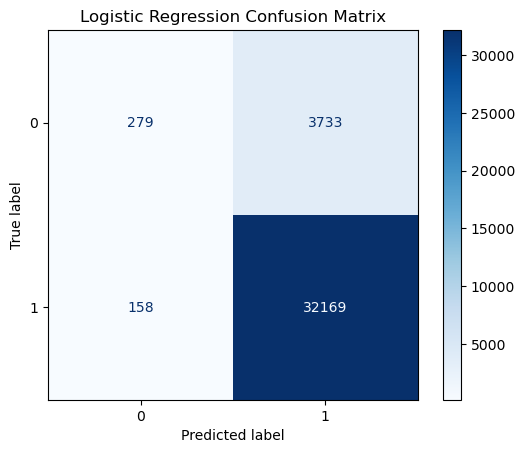

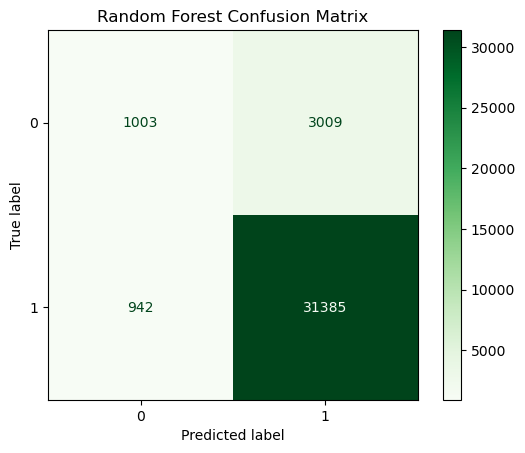

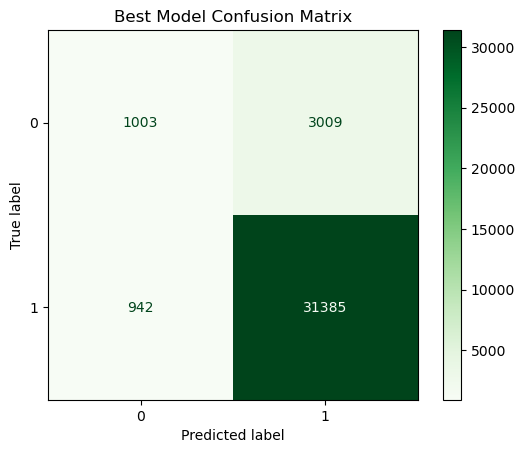

In [42]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr).astype(int)  # convert to int
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[0, 1])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf).astype(int)  # convert to int
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Best Model - Grid Search
cm_bm = confusion_matrix(y_test, y_pred).astype(int)
disp_bm = ConfusionMatrixDisplay(confusion_matrix=cm_bm, display_labels=[0, 1])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Best Model Confusion Matrix")
plt.show()

In [44]:
def evaluate_classifier(model, X_test, y_test, threshold=0.5, plot=True):
    """
    Evaluate a binary classifier with ROC-AUC, PR-AUC, F1-score
    Works for Logistic Regression, Random Forest, XGBoost, etc.
    
    Parameters:
    - model: trained classifier with predict_proba() method
    - X_test: test features
    - y_test: true labels
    - threshold: probability threshold for F1-score
    - plot: if True, plots ROC and PR curves
    
    Returns:
    - metrics dictionary with ROC-AUC, PR-AUC, F1
    """
    # Predict probabilities for positive class
    y_proba = model.predict_proba(X_test)[:,1]

    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    # F1-score
    y_pred = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)

    # Optional plots
    if plot:
        plt.figure(figsize=(12,5))

        # ROC Curve
        plt.subplot(1,2,1)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()

        # PR Curve
        plt.subplot(1,2,2)
        plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend()

        plt.tight_layout()
        plt.show()
 
    metrics = {'ROC-AUC': roc_auc, 'PR-AUC': pr_auc, 'F1-score': f1}
    return metrics


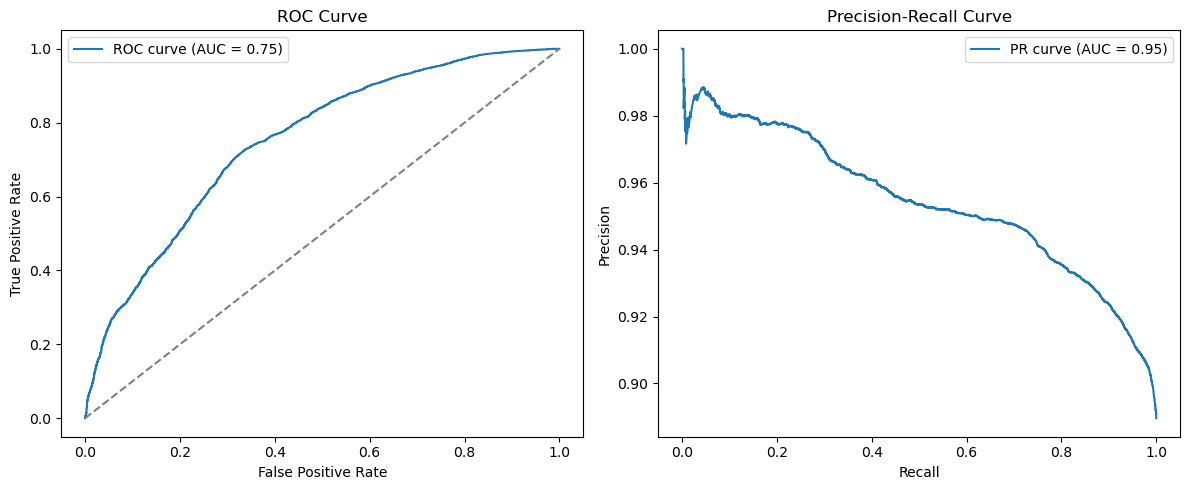

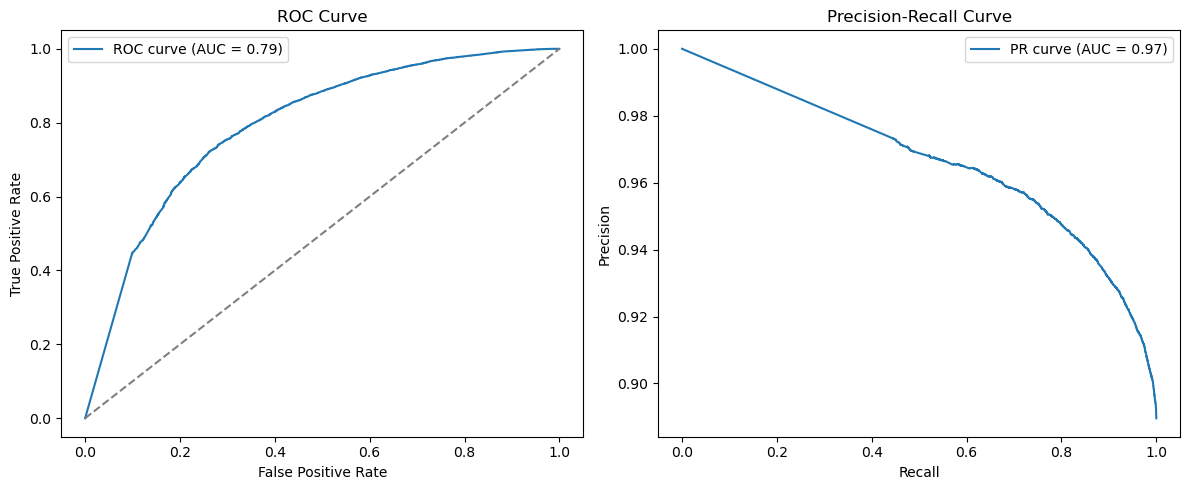

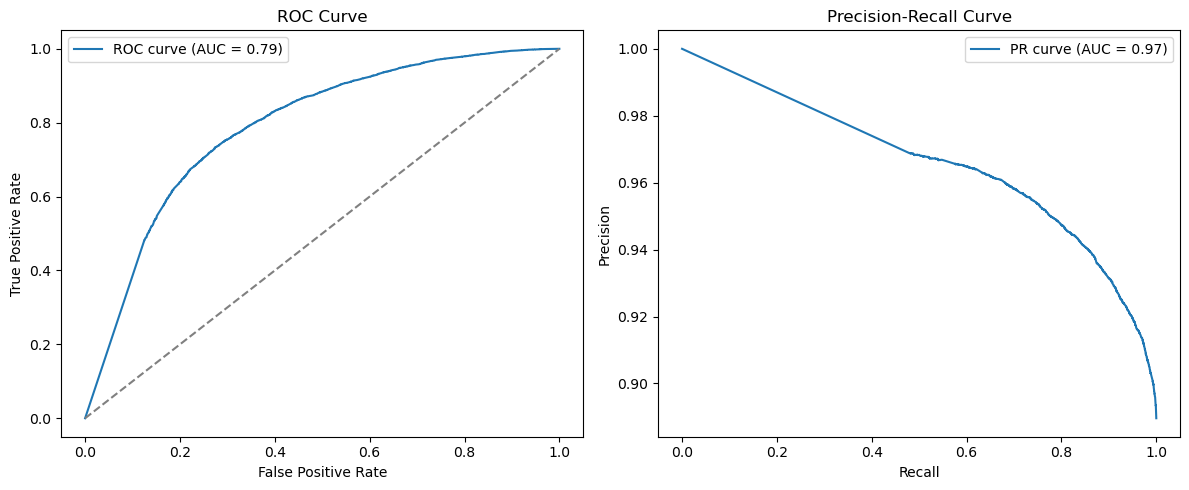

Logistic Regression: {'ROC-AUC': np.float64(0.7506771608335201), 'PR-AUC': np.float64(0.9543514850974888), 'F1-score': 0.9429714637470871}
Random Forest: {'ROC-AUC': np.float64(0.7929786829692504), 'PR-AUC': np.float64(0.966374123169904), 'F1-score': 0.9407921355891564}
Best Model: {'ROC-AUC': np.float64(0.7887261861829984), 'PR-AUC': np.float64(0.965819625793066), 'F1-score': 0.9408640067223865}


In [45]:
metrics_lr = evaluate_classifier(log_reg_model, X_test, y_test)
metrics_rfc = evaluate_classifier(rfc_model, X_test, y_test)
metrics_bm = evaluate_classifier(best_model, X_test, y_test)

# Compare metrics
print("Logistic Regression:", metrics_lr)
print("Random Forest:", metrics_rfc)
print("Best Model:", metrics_bm)

#### Finding 

